In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/hr_analytics.csv')
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0


In [3]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [4]:
df.dtypes

,0
enrollee_id,int64
city,object
city_development_index,float64
gender,object
relevent_experience,object
enrolled_university,object
education_level,object
major_discipline,object
experience,object
company_size,object


In [5]:
df.shape

(19158, 14)

In [6]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [7]:
df.tail()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0
19157,23834,city_67,0.855,NaN,No relevent experience,no_enrollment,Primary School,NaN,2,NaN,NaN,1,127,0.0


In [8]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [9]:
df['target'].value_counts()

,count
target,
0.0,14381
1.0,4777


In [10]:
dummy = pd.get_dummies(df[['gender', 'relevent_experience', 'enrolled_university',
                           'education_level', 'major_discipline', 'company_size',
                           'company_type', 'last_new_job']], drop_first=True, dtype=int)
dummy

,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_High School,education_level_Masters,education_level_Phd,education_level_Primary School,major_discipline_Business Degree,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
0,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1,0,0,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19154,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
19155,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
19156,1,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0


In [11]:
df1 = pd.concat([df,dummy],axis=1)
df1

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,...,0,0,0,0,0,0,0,0,0,0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,...,0,0,0,0,1,0,0,0,1,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,...,0,0,0,0,0,0,0,0,0,1
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,...,0,0,0,0,1,0,0,0,0,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,...,0,0,0,0,0,0,0,0,0,0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,...,0,0,0,0,0,0,0,1,0,0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,...,0,0,0,0,1,0,0,1,0,0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,...,0,0,0,0,1,1,0,0,0,0


In [12]:
df1 = df1.drop(['enrollee_id', 'city', 'gender', 'relevent_experience', 'enrolled_university',
                'education_level', 'major_discipline', 'company_size', 'company_type', 'last_new_job'], axis=1)
df1

,city_development_index,experience,training_hours,target,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_High School,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
0,0.920,>20,36,1.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0.776,15,47,0.0,1,0,1,0,1,0,...,0,0,0,0,1,0,0,0,1,0
2,0.624,5,83,0.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.789,<1,52,1.0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,0.767,>20,8,0.0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,0.878,14,42,1.0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
19154,0.920,14,52,1.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
19155,0.920,>20,44,0.0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
19156,0.802,<1,97,0.0,1,0,0,0,1,1,...,0,0,0,0,1,1,0,0,0,0


In [13]:
df1['experience'] = df1['experience'].str.replace('>', '')
df1['experience'] = df1['experience'].str.replace('<', '')
df1['experience'] = df1['experience'].str.replace('nan', '0')
df1['experience'] = df1['experience'].astype(float)
df1

,city_development_index,experience,training_hours,target,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_High School,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
0,0.920,20.0,36,1.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0.776,15.0,47,0.0,1,0,1,0,1,0,...,0,0,0,0,1,0,0,0,1,0
2,0.624,5.0,83,0.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.789,1.0,52,1.0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,0.767,20.0,8,0.0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,0.878,14.0,42,1.0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
19154,0.920,14.0,52,1.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
19155,0.920,20.0,44,0.0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
19156,0.802,1.0,97,0.0,1,0,0,0,1,1,...,0,0,0,0,1,1,0,0,0,0


In [14]:
df1['city_development_index'] = df1['city_development_index'].fillna(df1['city_development_index'].median())
df1['experience'] = df1['experience'].fillna(df1['experience'].median())
df1

,city_development_index,experience,training_hours,target,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_High School,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
0,0.920,20.0,36,1.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0.776,15.0,47,0.0,1,0,1,0,1,0,...,0,0,0,0,1,0,0,0,1,0
2,0.624,5.0,83,0.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.789,1.0,52,1.0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,0.767,20.0,8,0.0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,0.878,14.0,42,1.0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
19154,0.920,14.0,52,1.0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
19155,0.920,20.0,44,0.0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
19156,0.802,1.0,97,0.0,1,0,0,0,1,1,...,0,0,0,0,1,1,0,0,0,0


In [15]:
df1.isnull().sum()

,0
city_development_index,0
experience,0
training_hours,0
target,0
gender_Male,0
gender_Other,0
relevent_experience_No relevent experience,0
enrolled_university_Part time course,0
enrolled_university_no_enrollment,0
education_level_High School,0


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

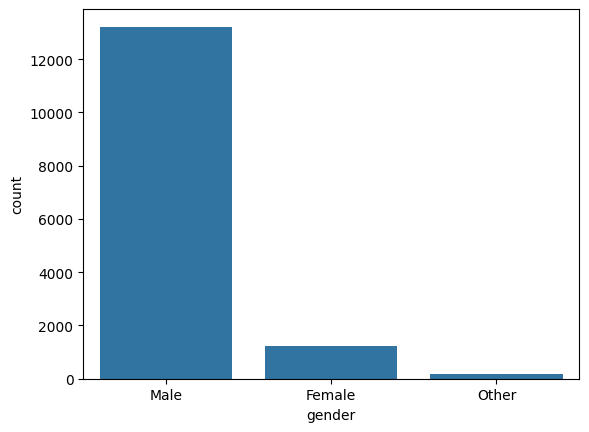

In [17]:
sns.countplot(x='gender', data=df)
plt.show()

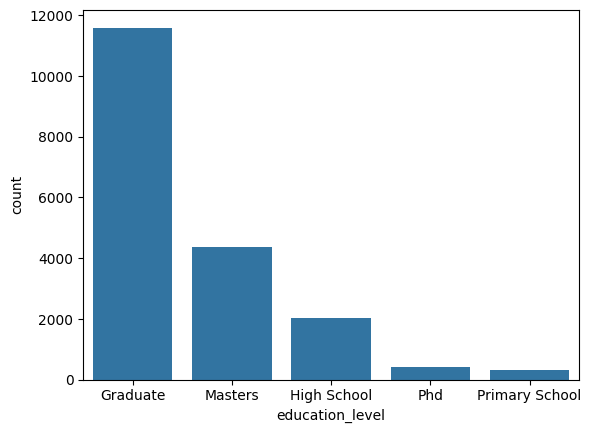

In [18]:
sns.countplot(x='education_level', data=df)
plt.show()

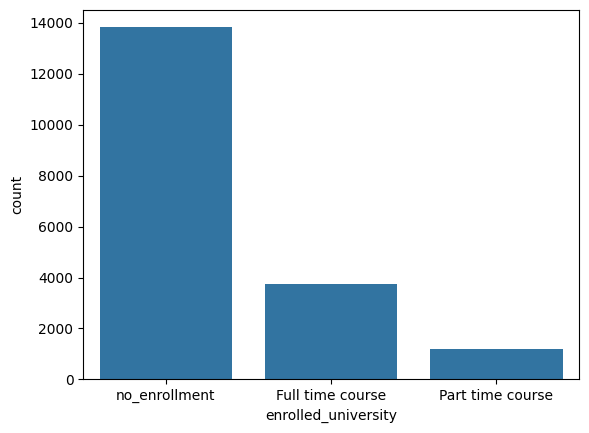

In [19]:
sns.countplot(x='enrolled_university', data=df)
plt.show()

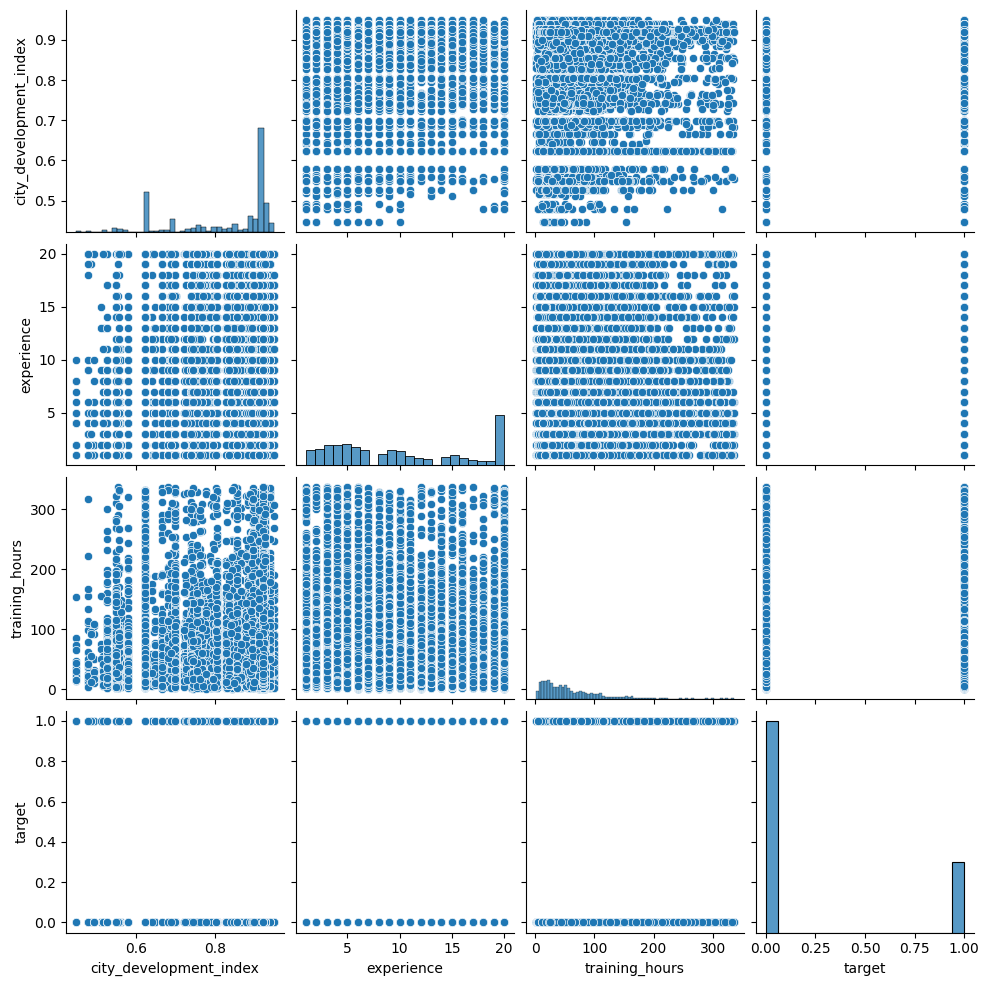

In [20]:
sns.pairplot(df1[['city_development_index', 'experience', 'training_hours', 'target']])
plt.show()

In [21]:
x = df1.drop(['target'], axis=1)
x

,city_development_index,experience,training_hours,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_High School,education_level_Masters,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
0,0.920,20.0,36,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.776,15.0,47,1,0,1,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0.624,5.0,83,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0.789,1.0,52,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,0.767,20.0,8,1,0,0,0,1,0,1,...,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,0.878,14.0,42,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
19154,0.920,14.0,52,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
19155,0.920,20.0,44,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
19156,0.802,1.0,97,1,0,0,0,1,1,0,...,0,0,0,0,1,1,0,0,0,0


In [22]:
y = df1['target']
y

,target
0,1.0
1,0.0
2,0.0
3,1.0
4,0.0
...,...
19153,1.0
19154,1.0
19155,0.0
19156,0.0


In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [25]:
y_pred = model.predict(x_test)
y_pred

array([ 0.11234344, -0.00648965,  0.21355231, ...,  0.29167947,
        0.18619022,  0.32823269])

In [26]:
print('slope = ',model.coef_)

slope =  [-1.07189946e+00 -3.35846005e-03 -1.87742808e-04 -1.32683786e-02
 -1.48360468e-03  4.09233358e-02 -5.06972512e-02 -4.28113324e-02
 -4.99146458e-02 -2.90672425e-02 -3.95893386e-02 -1.00046657e-01
  1.29144354e-01  1.09020765e-01  5.84976232e-02  8.00241839e-02
  1.02388913e-01 -1.34659209e-01 -1.27555939e-01 -1.01017622e-01
 -1.31850396e-01 -1.39996070e-01 -1.18524663e-01 -1.53927948e-01
 -1.31295610e-01 -6.68302745e-02  1.23467096e-02 -4.71159637e-02
 -8.81785568e-02  9.07030306e-03  1.84907135e-02  2.47007732e-02
  1.63967689e-02 -7.15380163e-02]


In [27]:
list(zip(x,model.coef_))

[('city_development_index', np.float64(-1.071899463029647)),
 ('experience', np.float64(-0.0033584600452589795)),
 ('training_hours', np.float64(-0.0001877428075495112)),
 ('gender_Male', np.float64(-0.013268378644614552)),
 ('gender_Other', np.float64(-0.0014836046849542128)),
 ('relevent_experience_No relevent experience',
  np.float64(0.04092333578017595)),
 ('enrolled_university_Part time course', np.float64(-0.05069725124215532)),
 ('enrolled_university_no_enrollment', np.float64(-0.04281133239052319)),
 ('education_level_High School', np.float64(-0.049914645758119026)),
 ('education_level_Masters', np.float64(-0.029067242483146145)),
 ('education_level_Phd', np.float64(-0.03958933856052341)),
 ('education_level_Primary School', np.float64(-0.10004665724520002)),
 ('major_discipline_Business Degree', np.float64(0.12914435376508984)),
 ('major_discipline_Humanities', np.float64(0.10902076537048257)),
 ('major_discipline_No Major', np.float64(0.05849762324803874)),
 ('major_discipli

In [28]:
print('constant = ',model.intercept_)

constant =  1.2804623539027757


In [29]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_pred)

0.3119197383114423

In [30]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(y_test,y_pred)

701056726024022.6

In [31]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

0.15681492798481614

In [32]:
z = np.sqrt(mean_squared_error(y_test,y_pred))
z

np.float64(0.39599864644316163)

In [33]:
from sklearn.metrics import r2_score
ac = r2_score(y_test,y_pred)
print('Accuracy =',ac)

Accuracy = 0.1678839392885063
